# Exploratory Data Analysis

Initial Univariate and bivariate exploration of the KPIs built in the previous notebooks, including the funnel-level KPIs (step conversion rate, time per step).

**Sections**

**1. KPI Grain Reference**

**2. Setup and Helpers**

**3. Client-level KPIs**

-   **Completion Rate**
-   **Error Rate**
-   **Time to Completion**
-   **Sessions per Client**
-   **Average Steps per Client**

**4. Events-level KPIs**

   - **Step-Conversation Rate**
   - **Time Spent by Step**


## KPI grain reference

| KPI                  | Grain  | Definition                                                     |
|----------------------|--------|----------------------------------------------------------------|
| Completion Rate      | client | % of clients that reached `confirm`                            |
| Time to Completion   | client | average time from `start` to `confirm` (completed visits only) |
| Avg Steps per Client | client | average number of steps recorded in the visit                  |
| Error Rate           | client | % of clients with at least one backward step                   |
| Step Conversion Rate | event  | % of visits at step N that reached step N+1                    |
| Time Spent per Step  | event  | average duration users spend on each step                      |
| Sessions per Client  | client | distinct visits per client                                     |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from scipy.stats.contingency import association

df_events = pd.read_csv("events_kpi_table.csv", parse_dates=["date_time"])
df_visits = pd.read_csv("visits_kpi_table.csv", parse_dates=["visit_start", "visit_end"])
df_clients = pd.read_csv("client_kpi_table.csv")

In [21]:
sns.set_theme(style="whitegrid")

def numeric_summary(df, cols=None):
    cols = cols or df.select_dtypes('number').columns.tolist()
    s = df[cols].describe().T
    s['skew'] = df[cols].skew()
    s['kurtosis'] = df[cols].kurtosis()
    s['missing_%'] = df[cols].isna().mean().mul(100)
    return s.round(3)

## Client-level KPIs

In [22]:
client_kpis = ['session_per_client','avg_steps_client', 'avg_time_to_completion', "completion_rate", "error_rate"]
numeric_summary(df_clients, cols=client_kpis)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,missing_%
session_per_client,50487.0,1.375,0.823,1.0,1.000,1.0,2.0,18.0,4.207,32.889,0.000
avg_steps_client,50487.0,4.899,2.599,1.0,3.333,5.0,6.0,80.0,3.331,51.937,0.000
avg_time_to_completion,19451.0,267.376,215.645,38.0,137.000,202.0,318.0,3403.0,3.095,16.789,61.473
completion_rate,50487.0,0.334,0.448,0.0,0.000,0.0,1.0,1.0,0.711,-1.375,0.000
error_rate,50487.0,0.433,0.462,0.0,0.000,0.2,1.0,1.0,0.270,-1.781,0.000


In [29]:
#Completion Rate

print(df_clients.groupby('Variation')["completion_rate"].agg(['count', 'mean', 'median', 'std']).round(3))

           count   mean  median    std
Variation                             
Control    23526  0.331     0.0  0.447
Test       26961  0.336     0.0  0.448


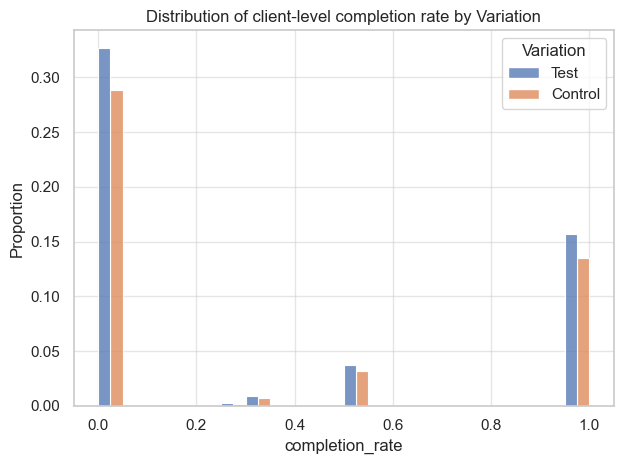

In [28]:
sns.histplot(data=df_clients, x='completion_rate', hue='Variation',
             bins=20, multiple='dodge', stat='proportion')
plt.title('Distribution of client-level completion rate by Variation')
plt.tight_layout(); plt.show()

           count   mean  median    std
Variation                             
Control    23526  0.402     0.0  0.458
Test       26961  0.460     0.5  0.463


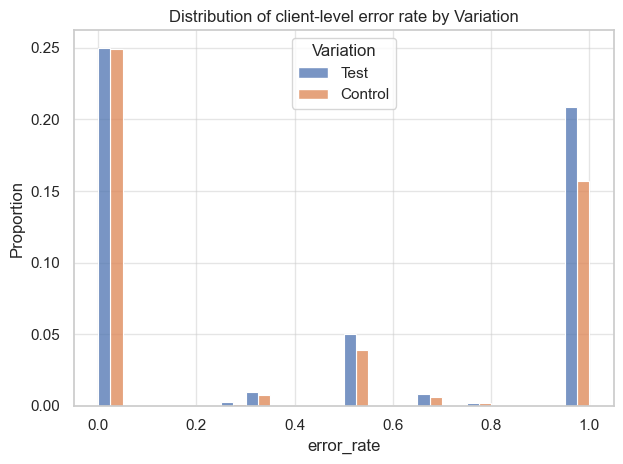

In [30]:
#Error Rate

print(df_clients.groupby('Variation')["error_rate"].agg(['count', 'mean', 'median', 'std']).round(3))

sns.histplot(data=df_clients, x='error_rate', hue='Variation',
             bins=20, multiple='dodge', stat='proportion')
plt.title('Distribution of client-level error rate by Variation')
plt.tight_layout(); plt.show()

           count   mean  median    std
Variation                             
Control    23526  1.370     1.0  0.836
Test       26961  1.379     1.0  0.811


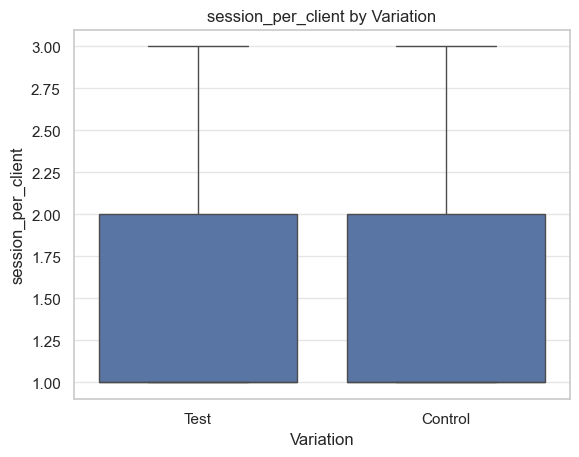

In [9]:
# Sessions per Client

print(df_clients.groupby('Variation')["session_per_client"].agg(['count', 'mean', 'median', 'std']).round(3))

sns.boxplot(data=df_clients, x='Variation', y="session_per_client", showfliers=False)
plt.title(f'{"session_per_client"} by Variation');
plt.show()

           count   mean  median    std
Variation                             
Control    23526  4.696     5.0  2.569
Test       26961  5.076     5.0  2.612


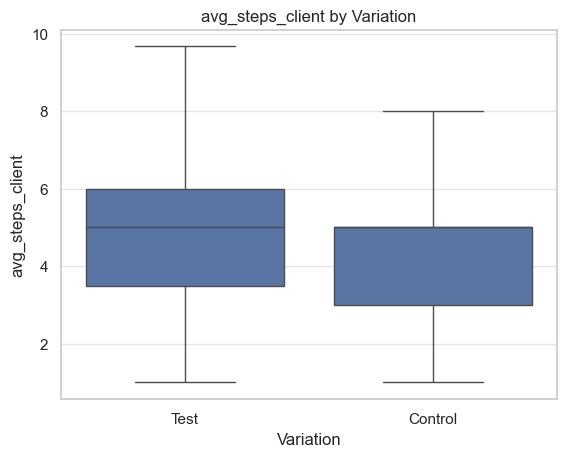

In [10]:
#Average Steps per Client

print(df_clients.groupby('Variation')["avg_steps_client"].agg(['count', 'mean', 'median', 'std']).round(3))

sns.boxplot(data=df_clients, x='Variation', y="avg_steps_client", showfliers=False)
plt.title(f'{"avg_steps_client"} by Variation'); plt.show()

           count    mean  median     std
Variation                               
Control     8978  289.90   226.0  217.03
Test       10473  248.07   184.0  212.57


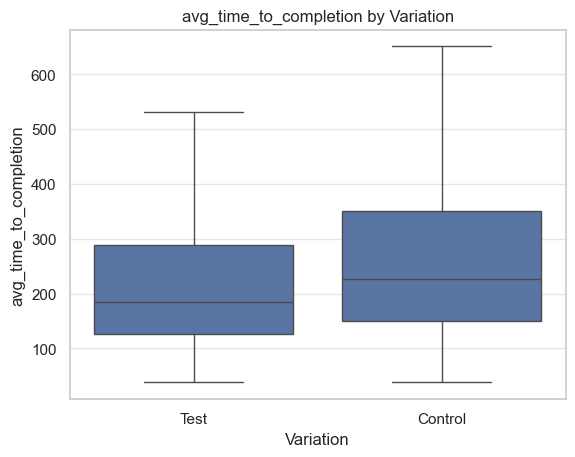

In [11]:
#Average Time to Completion

print(df_clients.groupby('Variation')["avg_time_to_completion"].agg(['count', 'mean', 'median', 'std']).round(2))

sns.boxplot(data=df_clients, x='Variation', y="avg_time_to_completion", showfliers=False)
plt.title(f'{"avg_time_to_completion"} by Variation'); plt.show()

## Visit-level KPIs

In [12]:
if 'Variation' not in df_events.columns:
    df_events = df_events.merge(df_clients[['client_id', 'Variation']],
                                on='client_id', how='left')

In [13]:
#Step Conversion Rate

step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

funnel = df_events.groupby('process_step')['visit_id'].nunique().reindex(step_order).reset_index(name='n_visits')

funnel['conversion_rate'] = funnel['n_visits'] / funnel['n_visits'].shift(1)

funnel

,process_step,n_visits,conversion_rate
0,start,144902,NaN
1,step_1,119255,0.823005
2,step_2,104341,0.874940
3,step_3,95093,0.911368
4,confirm,89826,0.944612


In [14]:
parts = []
for variation, sub in df_events.groupby('Variation'):
    f = (sub.groupby('process_step')['visit_id'].nunique()
            .reindex(step_order)
            .reset_index(name='n_visits'))
    f['conversion_rate'] = f['n_visits'] / f['n_visits'].shift(1)
    f['Variation'] = variation
    parts.append(f)

funnel_var = pd.concat(parts, ignore_index=True)
funnel_var

,process_step,n_visits,conversion_rate,Variation
0,start,30903,NaN,Control
1,step_1,23541,0.761771,Control
2,step_2,20131,0.855146,Control
3,step_3,18293,0.908698,Control
4,confirm,16039,0.876783,Control
5,start,33144,NaN,Test
6,step_1,28274,0.853065,Test
7,step_2,24493,0.866273,Test
8,step_3,22180,0.905565,Test
9,confirm,21725,0.979486,Test


In [15]:
pivot = (funnel_var.pivot(index='process_step',
                          columns='Variation',
                          values='conversion_rate')
            .reindex(step_order))
pivot['diff'] = (pivot['Test'] - pivot['Control']).round(4)
pivot

Variation,Control,Test,diff
process_step,,,
start,NaN,NaN,NaN
step_1,0.761771,0.853065,0.0913
step_2,0.855146,0.866273,0.0111
step_3,0.908698,0.905565,-0.0031
confirm,0.876783,0.979486,0.1027


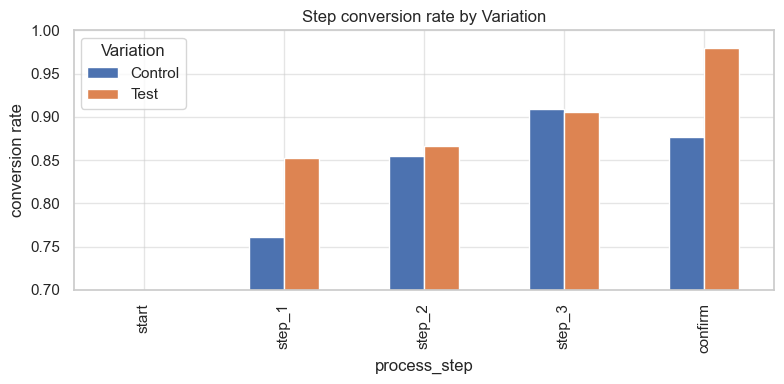

In [16]:
pivot[['Control', 'Test']].plot(kind='bar', figsize=(8, 4),
                                title='Step conversion rate by Variation')
plt.ylabel('conversion rate')
plt.ylim(0.7, 1.0)
plt.tight_layout(); plt.show()

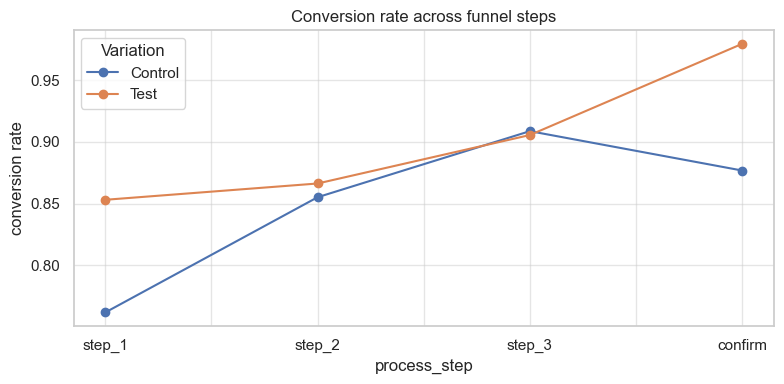

In [17]:
pivot[['Control', 'Test']].plot(kind='line', marker='o', figsize=(8, 4),
                                title='Conversion rate across funnel steps')
plt.ylabel('conversion rate'); plt.tight_layout(); plt.show()

In [18]:
#Average Time Spent per Step

time_per_step = df_events[df_events["process_step"] != "confirm"].groupby('process_step')['time_on_each_step'].mean().reset_index()

time_per_step

,process_step,time_on_each_step
0,start,139.024150
1,step_1,39.439692
2,step_2,45.788994
3,step_3,99.382272


In [19]:
time_avg = (df_events[df_events['process_step'] != 'confirm']
              .groupby(['visit_id', 'process_step', 'Variation'])['time_on_each_step']
              .mean()
              .reset_index())

time_avg = time_avg.groupby(['Variation', 'process_step'])['time_on_each_step'] \
         .mean().unstack().round(2)

time_avg

process_step,start,step_1,step_2,step_3
Variation,,,,
Control,143.91,40.70,37.11,95.34
Test,142.98,33.63,41.76,93.59


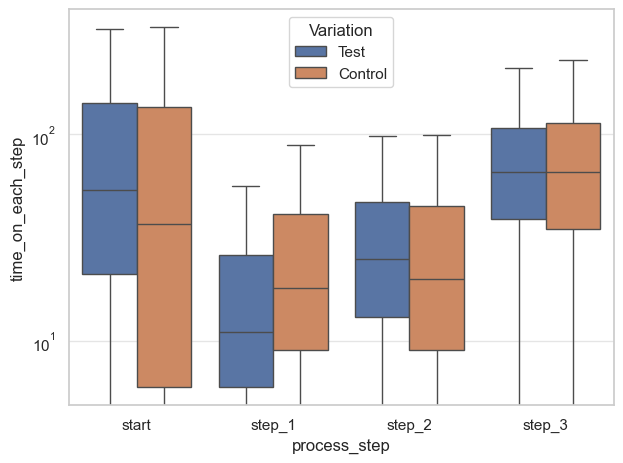

In [20]:
sns.boxplot(data=df_events[df_events['process_step'] != 'confirm'],
            x='process_step', y='time_on_each_step',
            hue='Variation', order=step_order[:-1], showfliers=False)
plt.yscale('log')
plt.tight_layout(); plt.show()

### Summary of findings